# Netflix Titles Analysis

In this notebook I am looking through the Netflix titles dataset to understand what kind of content is there. I wanted to check things like content type, genre, country, release year, and also the description text.

Main parts of the notebook:
- data cleaning
- missing values
- univariate analysis
- bivariate analysis
- time analysis
- country and genre analysis
- text analysis
- final observations

In [1]:
%matplotlib inline

from pathlib import Path
from collections import Counter
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
file_path = Path("../netflix_titles.csv/netflix_titles.csv")
df = pd.read_csv(file_path)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 1. Data Cleaning

I started by cleaning a few columns so the data would be easier to work with.

In [3]:
df.columns = df.columns.str.strip()

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

df["main_country"] = df["country"].fillna("Unknown").str.split(",").str[0].str.strip()
df["main_genre"] = df["listed_in"].fillna("Unknown").str.split(",").str[0].str.strip()

df["duration_number"] = df["duration"].str.extract(r"(\d+)")
df["duration_number"] = pd.to_numeric(df["duration_number"], errors="coerce")

df["movie_minutes"] = df.apply(lambda x: x["duration_number"] if x["type"] == "Movie" else pd.NA, axis=1)
df["tv_seasons"] = df.apply(lambda x: x["duration_number"] if x["type"] == "TV Show" else pd.NA, axis=1)
df["years_to_add"] = df["year_added"] - df["release_year"]

df = df.drop_duplicates(subset="show_id")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,main_country,main_genre,duration_number,movie_minutes,tv_seasons,years_to_add
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September,United States,Documentaries,90.0,90.0,<NA>,1.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September,South Africa,International TV Shows,2.0,<NA>,2.0,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September,Unknown,Crime TV Shows,1.0,<NA>,1.0,0.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September,Unknown,Docuseries,1.0,<NA>,1.0,0.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September,India,International TV Shows,2.0,<NA>,2.0,0.0


In [4]:
print("Rows and columns:", df.shape)
print()
print(df.dtypes)

Rows and columns: (8807, 20)

show_id                    object
type                       object
title                      object
director                   object
cast                       object
country                    object
date_added         datetime64[ns]
release_year                int64
rating                     object
duration                   object
listed_in                  object
description                object
year_added                float64
month_added                object
main_country               object
main_genre                 object
duration_number           float64
movie_minutes              object
tv_seasons                 object
years_to_add              float64
dtype: object


## 2. Missing Values Analysis

Here I am checking which columns have missing values.

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

missing_df

,missing_count,missing_percent
tv_seasons,6131,69.62
movie_minutes,2679,30.42
director,2634,29.91
country,831,9.44
cast,825,9.37
month_added,98,1.11
date_added,98,1.11
year_added,98,1.11
years_to_add,98,1.11
rating,4,0.05


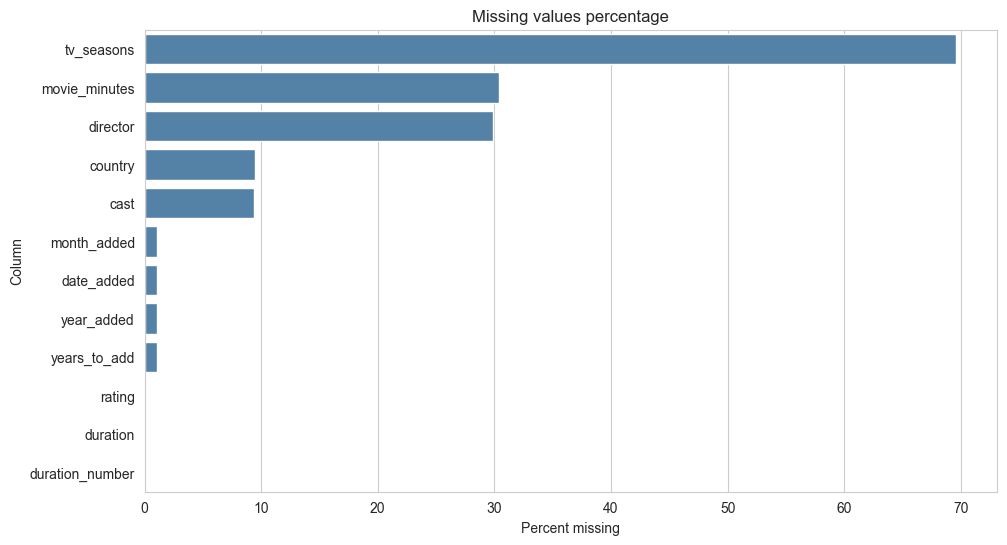

In [6]:
missing_plot = missing_df[missing_df["missing_count"] > 0].reset_index()
missing_plot.columns = ["column", "missing_count", "missing_percent"]

plt.figure(figsize=(11, 6))
sns.barplot(data=missing_plot, x="missing_percent", y="column", color="steelblue")
plt.title("Missing values percentage")
plt.xlabel("Percent missing")
plt.ylabel("Column")
plt.show()

## 3. Univariate Analysis

In this part I am looking at one variable at a time to get a basic idea of the dataset.

C:\Users\ismai\AppData\Local\Temp\ipykernel_26680\2459144167.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette="Set2")


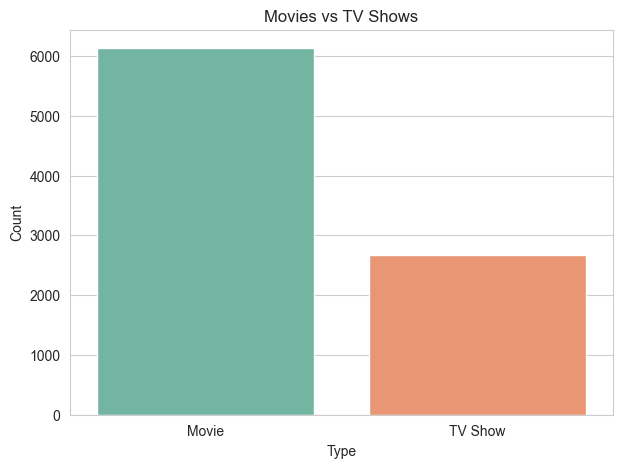

In [7]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, palette="Set2")
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

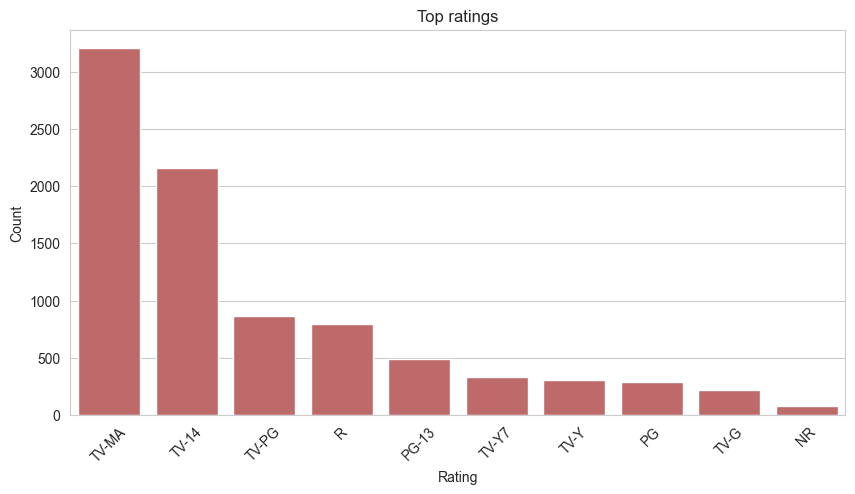

In [8]:
rating_counts = df["rating"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, color="indianred")
plt.title("Top ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

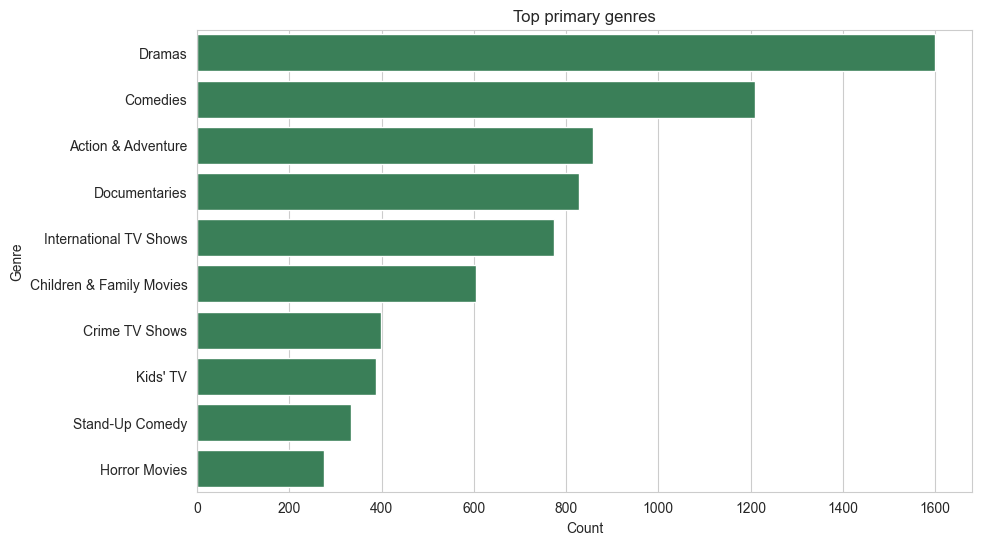

In [9]:
genre_counts = df["main_genre"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color="seagreen")
plt.title("Top primary genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

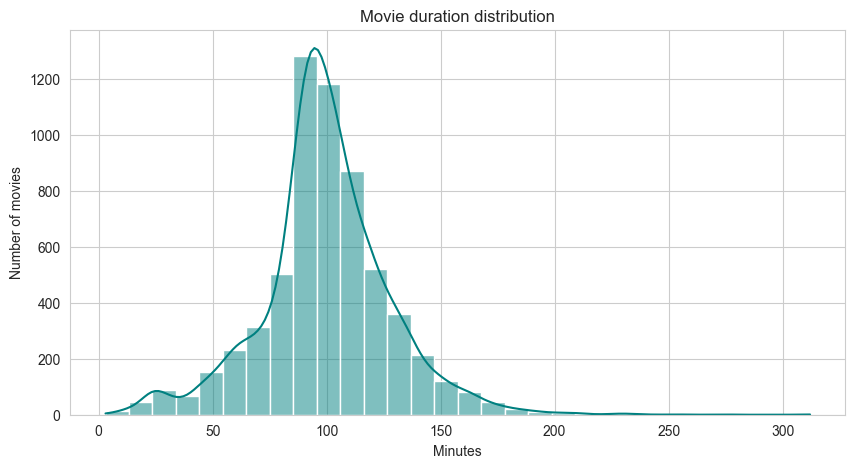

In [10]:
movie_time = df[df["type"] == "Movie"]["movie_minutes"].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(movie_time, bins=30, kde=True, color="teal")
plt.title("Movie duration distribution")
plt.xlabel("Minutes")
plt.ylabel("Number of movies")
plt.show()

## 4. Bivariate Analysis

In this part I compare two variables together to see if there are any patterns.

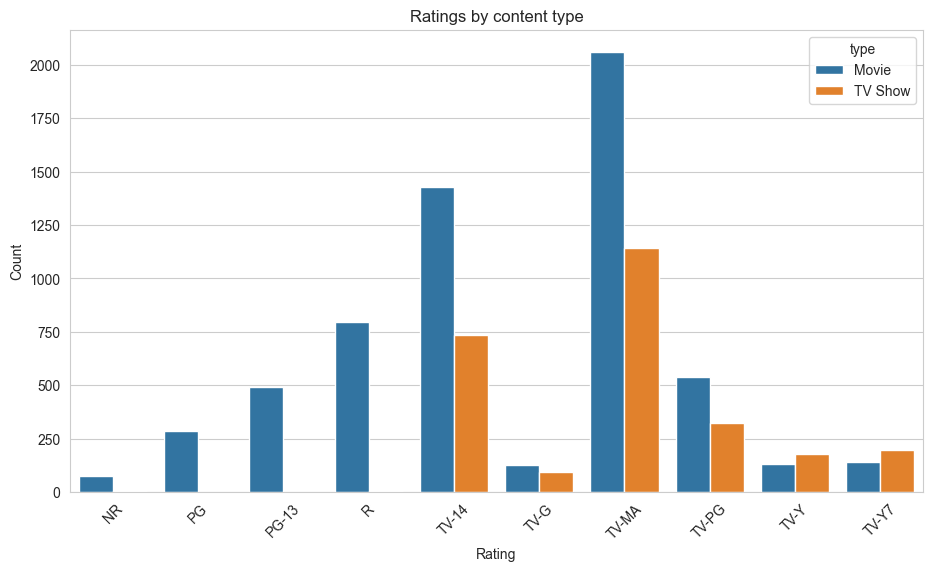

In [11]:
rating_type = df.groupby(["rating", "type"]).size().reset_index(name="count")
top_rating_names = df["rating"].value_counts().head(10).index
rating_type = rating_type[rating_type["rating"].isin(top_rating_names)]

plt.figure(figsize=(11, 6))
sns.barplot(data=rating_type, x="rating", y="count", hue="type")
plt.title("Ratings by content type")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

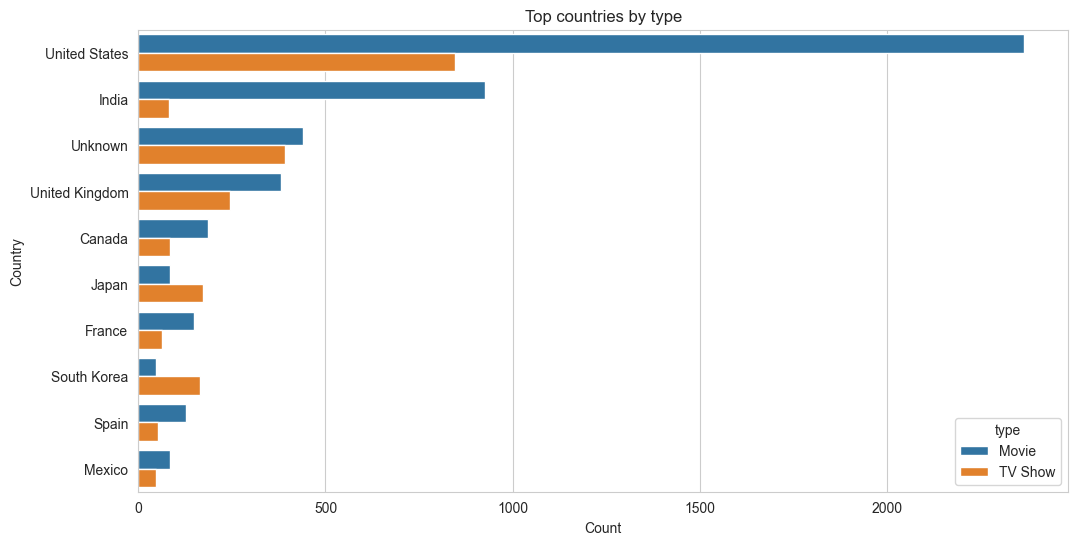

In [12]:
top_countries = df["main_country"].value_counts().head(10).index
country_type = df[df["main_country"].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.countplot(data=country_type, y="main_country", hue="type", order=top_countries)
plt.title("Top countries by type")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

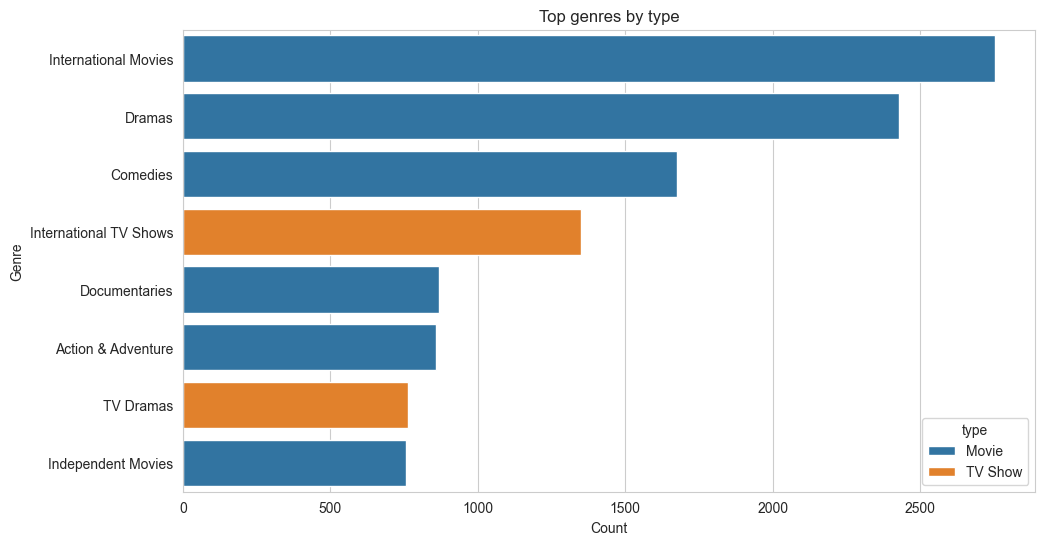

In [13]:
temp = df[["type", "listed_in"]].dropna().copy()
temp["listed_in"] = temp["listed_in"].str.split(",")
temp = temp.explode("listed_in")
temp["listed_in"] = temp["listed_in"].str.strip()

top_genres = temp["listed_in"].value_counts().head(8).index
temp = temp[temp["listed_in"].isin(top_genres)]

plt.figure(figsize=(11, 6))
sns.countplot(data=temp, y="listed_in", hue="type", order=top_genres)
plt.title("Top genres by type")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

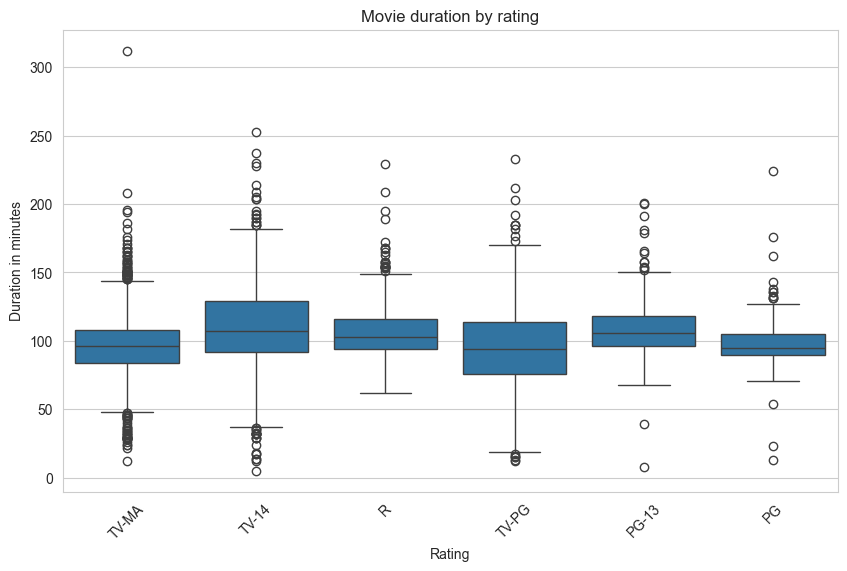

In [14]:
movie_rating_data = df[df["type"] == "Movie"][["rating", "movie_minutes"]].dropna()
top_movie_ratings = movie_rating_data["rating"].value_counts().head(6).index
movie_rating_data = movie_rating_data[movie_rating_data["rating"].isin(top_movie_ratings)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=movie_rating_data, x="rating", y="movie_minutes", order=top_movie_ratings)
plt.title("Movie duration by rating")
plt.xlabel("Rating")
plt.ylabel("Duration in minutes")
plt.xticks(rotation=45)
plt.show()

## 5. Time-Series Analysis

Next I wanted to see how the content changes over time.

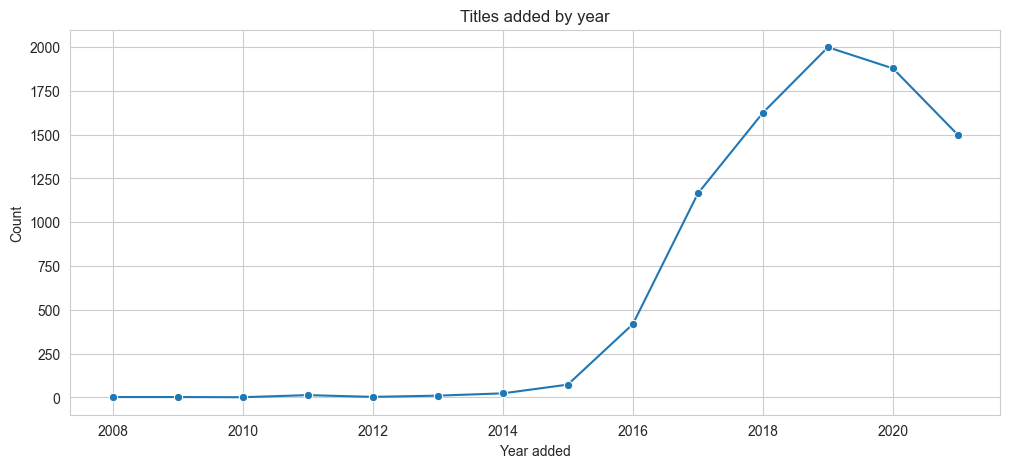

In [15]:
added_year = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=added_year.index, y=added_year.values, marker="o")
plt.title("Titles added by year")
plt.xlabel("Year added")
plt.ylabel("Count")
plt.show()

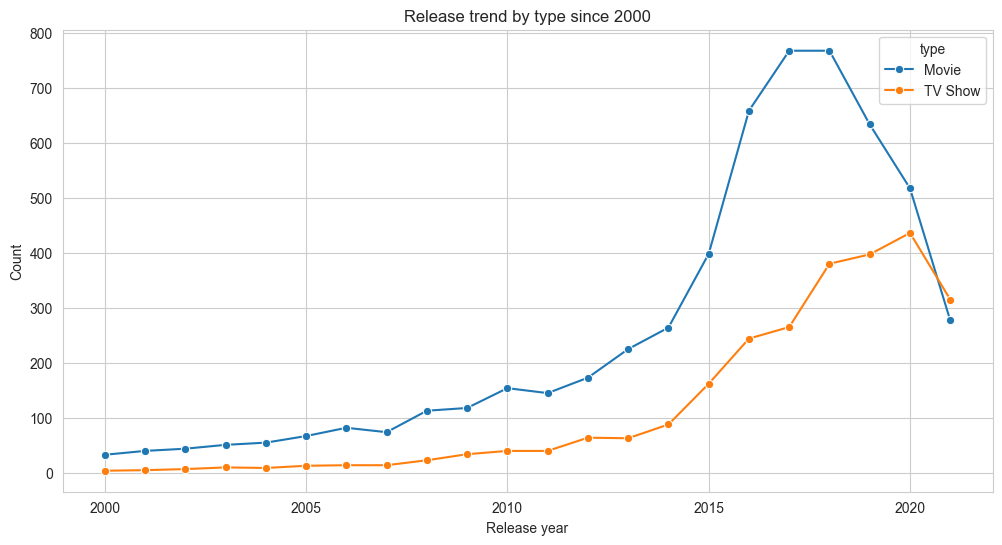

In [16]:
release_type = df.groupby(["release_year", "type"]).size().reset_index(name="count")
release_type = release_type[release_type["release_year"] >= 2000]

plt.figure(figsize=(12, 6))
sns.lineplot(data=release_type, x="release_year", y="count", hue="type", marker="o")
plt.title("Release trend by type since 2000")
plt.xlabel("Release year")
plt.ylabel("Count")
plt.show()

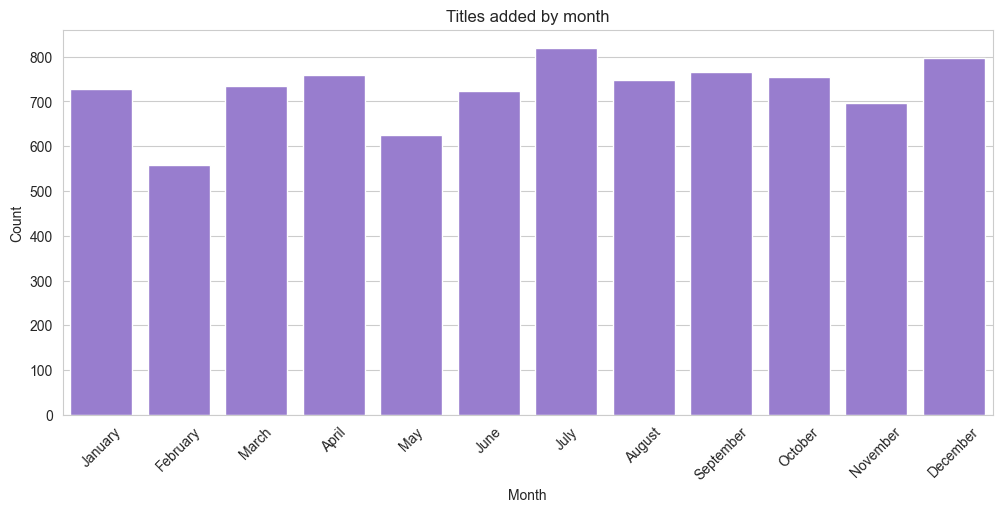

In [17]:
months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

month_counts = df["month_added"].value_counts().reindex(months)

plt.figure(figsize=(12, 5))
sns.barplot(x=month_counts.index, y=month_counts.values, color="mediumpurple")
plt.title("Titles added by month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

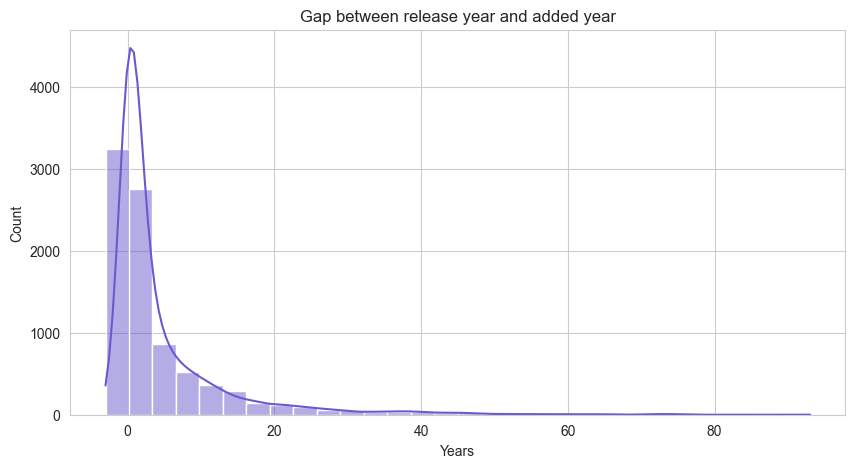

count    8709.000000
mean        4.690894
std         8.792208
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: years_to_add, dtype: float64

In [18]:
gap_data = df["years_to_add"].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(gap_data, bins=30, kde=True, color="slateblue")
plt.title("Gap between release year and added year")
plt.xlabel("Years")
plt.ylabel("Count")
plt.show()

gap_data.describe()

## 6. Country and Genre Deep Dive

This part is more focused on where the content comes from and what genres appear the most.

In [19]:
country_genre = df[df["main_country"].isin(top_countries)].groupby(["main_country", "main_genre"]).size().reset_index(name="count")
country_genre = country_genre.sort_values(["main_country", "count"], ascending=[True, False])
country_genre.groupby("main_country").head(3)

,main_country,main_genre,count
1,Canada,Children & Family Movies,39
7,Canada,Dramas,37
5,Canada,Documentaries,33
33,France,Dramas,52
29,France,Comedies,26
26,France,Action & Adventure,24
51,India,Dramas,404
46,India,Comedies,267
42,India,Action & Adventure,130
62,Japan,Anime Series,136


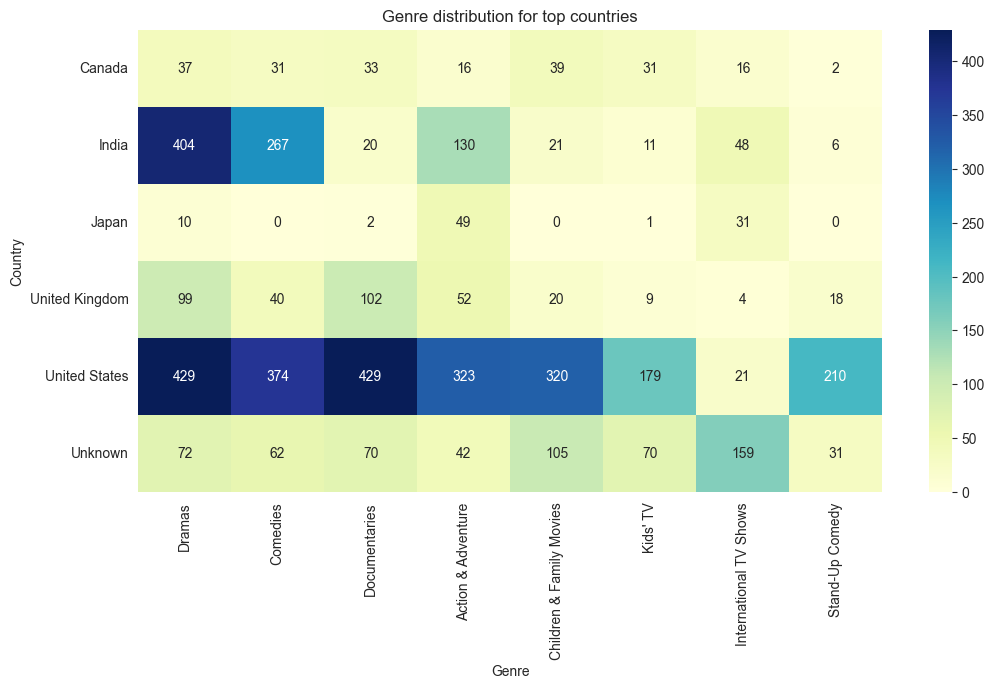

In [20]:
small = df[df["main_country"].isin(top_countries[:6])]
heat = pd.crosstab(small["main_country"], small["main_genre"])
heat = heat.loc[:, heat.sum().sort_values(ascending=False).head(8).index]

plt.figure(figsize=(12, 6))
sns.heatmap(heat, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Genre distribution for top countries")
plt.xlabel("Genre")
plt.ylabel("Country")
plt.show()

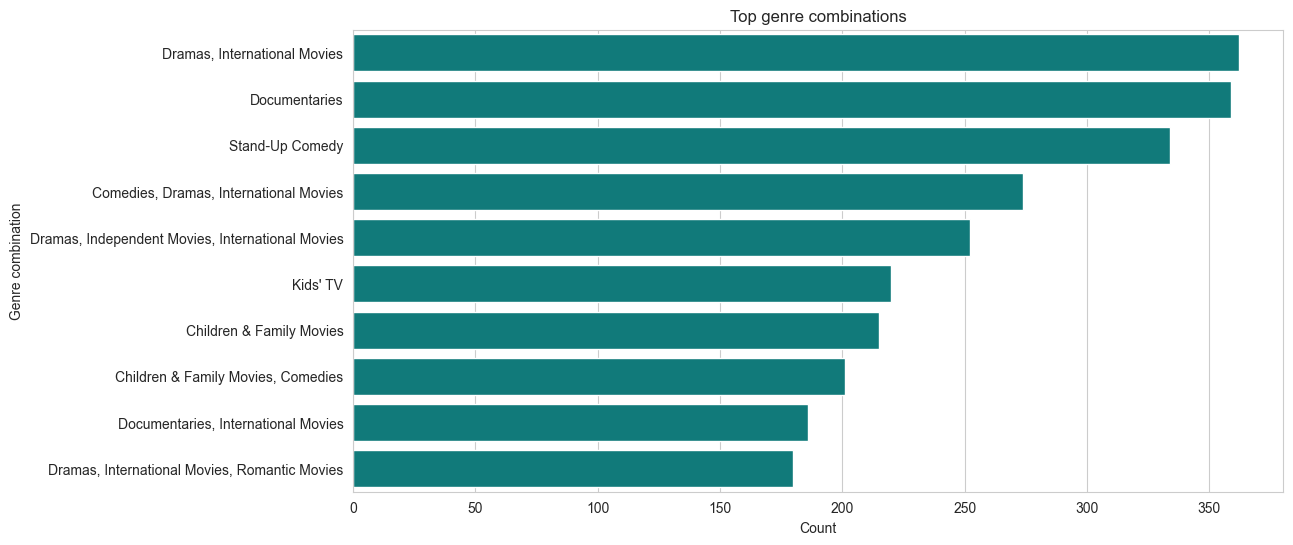

In [21]:
genre_mix = df["listed_in"].dropna().value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_mix.values, y=genre_mix.index, color="darkcyan")
plt.title("Top genre combinations")
plt.xlabel("Count")
plt.ylabel("Genre combination")
plt.show()

## 7. Text Analysis on Descriptions

I also used the description column because it can show repeated words and general themes in the dataset.

In [22]:
stop_words = {
    "the", "and", "for", "with", "that", "this", "from", "into", "their", "they", "them",
    "about", "after", "before", "while", "where", "when", "over", "under", "into", "have",
    "has", "been", "his", "her", "she", "he", "its", "who", "must", "life", "young", "find"
}

all_text = " ".join(df["description"].dropna().str.lower())
words = re.findall(r"[a-z']+", all_text)
words = [w for w in words if w not in stop_words and len(w) > 3]

common_words = pd.DataFrame(Counter(words).most_common(15), columns=["word", "count"])
common_words

,word,count
0,family,589
1,world,528
2,love,503
3,woman,463
4,friends,439
5,series,395
6,documentary,364
7,school,325
8,home,316
9,finds,313


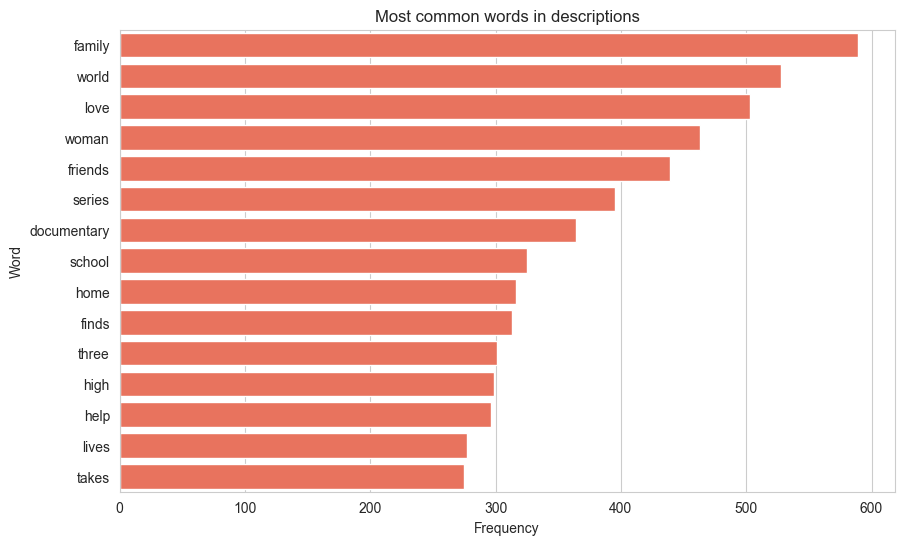

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(data=common_words, x="count", y="word", color="tomato")
plt.title("Most common words in descriptions")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

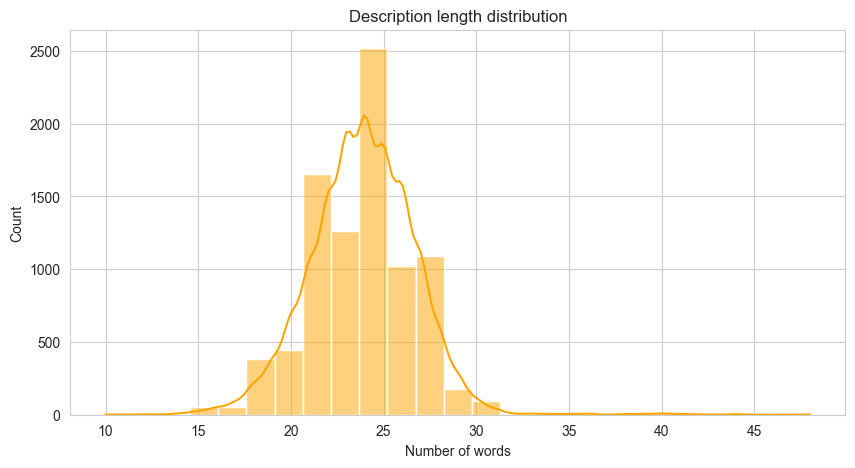

count    8807.000000
mean       23.882253
std         2.836704
min        10.000000
25%        22.000000
50%        24.000000
75%        26.000000
max        48.000000
Name: description, dtype: float64

In [24]:
desc_len = df["description"].dropna().str.split().str.len()

plt.figure(figsize=(10, 5))
sns.histplot(desc_len, bins=25, kde=True, color="orange")
plt.title("Description length distribution")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

desc_len.describe()

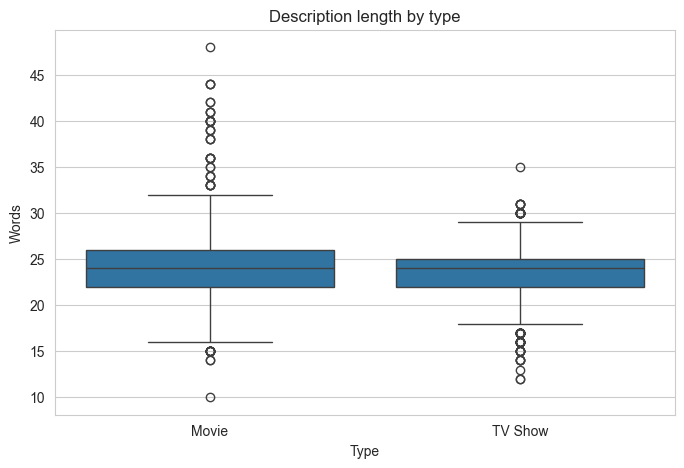

In [25]:
desc_type = df[["type", "description"]].dropna().copy()
desc_type["desc_length"] = desc_type["description"].str.split().str.len()

plt.figure(figsize=(8, 5))
sns.boxplot(data=desc_type, x="type", y="desc_length")
plt.title("Description length by type")
plt.xlabel("Type")
plt.ylabel("Words")
plt.show()

## 8. Final Insights and Conclusions

In [26]:
summary = pd.DataFrame({
    "metric": [
        "total titles",
        "movies",
        "tv shows",
        "top country",
        "top genre",
        "most common rating",
        "avg movie duration",
        "avg tv show seasons",
        "avg years to add"
    ],
    "value": [
        len(df),
        int((df["type"] == "Movie").sum()),
        int((df["type"] == "TV Show").sum()),
        df["main_country"].value_counts().idxmax(),
        df["main_genre"].value_counts().idxmax(),
        df["rating"].value_counts().idxmax(),
        round(df["movie_minutes"].dropna().mean(), 2),
        round(df["tv_seasons"].dropna().mean(), 2),
        round(df["years_to_add"].dropna().mean(), 2)
    ]
})

summary

,metric,value
0,total titles,8807
1,movies,6131
2,tv shows,2676
3,top country,United States
4,top genre,Dramas
5,most common rating,TV-MA
6,avg movie duration,99.58
7,avg tv show seasons,1.76
8,avg years to add,4.69


### Final notes

- Movies appear more often than TV shows in this dataset.
- The content is not evenly spread across countries because a few countries show up much more than the rest.
- Some genres like drama and international content seem to appear a lot.
- The number of titles added to Netflix grows more in the later years.
- There are many titles that were added to Netflix some years after they were first released.
- The description text is also useful because it gives another way to spot common themes.

After running the notebook, these points can be edited based on the charts and values shown above.